In [23]:
import numpy as np 
import matplotlib.pyplot as plt
# for kDTree 
from scipy import spatial
# for quick and dirty performance measurnment 
import time
from datetime import timedelta 

# Setup 

Start with 2D simulation, particles in a square grid with some intial random velocities. We will use velocity-Verlet algorithm in NVE Ensenble with periodic boundary conditions (PBC crossings cause the odd vertical/horizontal stripes in the plots).  We will put 196 particles in a 15x15 box, spaced on a square lattice with distance 1. 

In [24]:
def set_up_system(num_particles,boxsize,kT,mass):
    # inital positions & velocities 
    # square lattice in 2D 
    X, Y = np.mgrid[1:(boxsize-1):(boxsize-1)*1j,1:(boxsize-1):(boxsize-1)*1j]
    positions = np.vstack([X.ravel(), Y.ravel()]).T
    positions = positions[:num_particles]
    # NVE, but we set some inital random velocities according to Maxwell-Boltzmann 
    # at some temperature kT to make sure particles move
    vel_x = np.random.normal(0.0, np.sqrt(kT/mass), num_particles)
    vel_y = np.random.normal(0.0, np.sqrt(kT/mass), num_particles)
    velocities = np.vstack([vel_x,vel_y]).T
    return positions, velocities

# No Neighbor List 

Do simple MD simulation, typical parameters, LJ interactions. Note that this is NOT the best code, since everything is mushed together where it should be nicely seperated into functions. This is just for demonstration. We use a timestep of $\delta t = 0.005$, and the following LJ parameters: $\epsilon=1$, $\sigma=1$ with a cutoff of $3\sigma$.

Note the double $N$ loop over all particles for the force calculations. This is by far the most expensive part of the simulation. 

simulation took: 0:00:50.527149
total forces calculated:  19110000


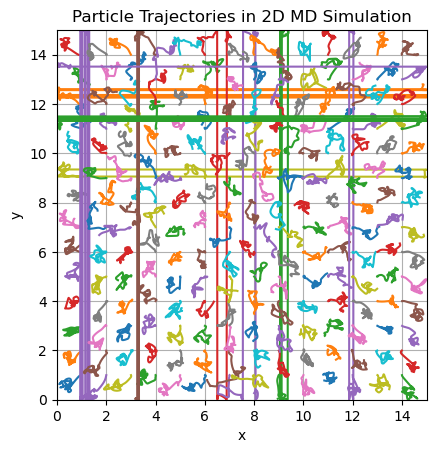

In [27]:
dt = 0.005
num_steps = 500
num_particles = 196
boxsize = 15.0

epsilon = 1.0
sigma = 1.0
cutoff = 3.0
mass = 1.0

kT = 0.5 


def compute_forces_brute_force(positions, sigma, epsilon, cutoff,boxsize,counter):
    forces = np.zeros_like(positions)
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            rij = positions[i] - positions[j]
            rij -= boxsize * np.round(rij / boxsize)  # Periodic boundary conditions
            r2 = np.dot(rij, rij)
            counter +=1
            if r2 <= (cutoff * sigma)**2:
                r6 = r2**3
                r12 = r6**2
                f_mag = 24 * epsilon * (2 * sigma**12 / r12 - sigma**6 / r6) / r2
                f_vec = f_mag * rij
                forces[i] += f_vec
                forces[j] -= f_vec
    return forces,counter


positions, velocities = set_up_system(num_particles,boxsize,kT,mass)
trajectories = np.zeros((num_steps, num_particles, 2))

counter = 0 
t0 = time.perf_counter()
# Velocity Verlet integration
for step in range(num_steps):
    # half-step velocity update 
    forces,counter = compute_forces_brute_force(positions, sigma, epsilon, cutoff,boxsize,counter)    
    velocities += 0.5 * (forces) / mass * dt

    # position update
    positions += velocities * dt   
    positions %= boxsize  # Apply periodic boundary conditions
    forces,counter = compute_forces_brute_force(positions, sigma, epsilon, cutoff,boxsize,counter)  

    # half-step velocity update 
    velocities += 0.5 * (forces) / mass * dt
    
    trajectories[step] = positions

t1 = time.perf_counter()

duration = timedelta(seconds=t1-t0)
print("simulation took:", duration)
print("total forces calculated: ",counter)

# Visualization
for i in range(num_particles):
    plt.plot(trajectories[:, i, 0], trajectories[:, i, 1])
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, boxsize)
plt.ylim(0, boxsize)
plt.title('Particle Trajectories in 2D MD Simulation')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()

# Simulation with KDTree for Neighborlist 

We repeat the exact same simulation, except for in the force calculation we build a tree and change the inner of the two loops over all particles to be only over the neighbors. We are lazy because we re-build the neighborlist every step, one can improve performance further if the neighborlist only gets rebuilt if particles have moved "sufficiently far" - this needs tuning. Rebuilding every step is safer and easier, but slightly more expensive. 

By using a neighbor list we have to calculate less forces, saving computational time.  

simulation took: 0:00:23.677960
total forces calculated:  4541466


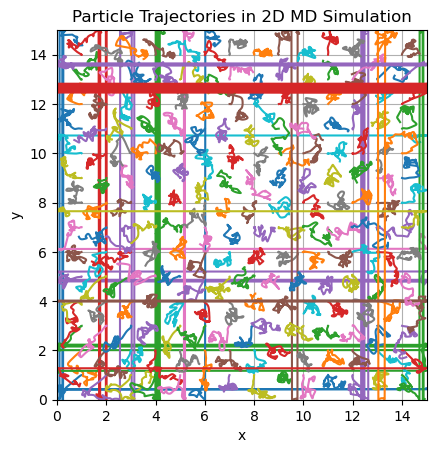

In [28]:
positions, velocities = set_up_system(num_particles,boxsize,kT,mass)
trajectories = np.zeros((num_steps, num_particles, 2))

def compute_forces_kDTree(positions, sigma, epsilon, cutoff,counter):
    forces = np.zeros_like(positions)
    for i in range(num_particles):
        # build the tree = neighbor list 
        tree = spatial.cKDTree(positions,boxsize=np.array([boxsize,boxsize]))
        neighbors  = tree.query_ball_point(positions[i], 3.0)
        for n in neighbors:
            if i != n:
                rij = positions[i] - positions[n]
                rij -= boxsize * np.round(rij / boxsize)  # Periodic boundary conditions
                r2 = np.dot(rij, rij)
                counter += 1
                if r2 <= (cutoff * sigma)**2:
                    r6 = r2**3
                    r12 = r6**2
                    f_mag = 24 * epsilon * (2 * sigma**12 / r12 - sigma**6 / r6) / r2
                    f_vec = f_mag * rij
                    forces[i] += f_vec
                    forces[n] -= f_vec
                else:
                    print(i,n, r2)
    return forces,counter

counter2 = 0 
t0 = time.perf_counter()
# Velocity Verlet integration
for step in range(num_steps):
    # half-step velocity update 
    forces,counter2 = compute_forces_kDTree(positions, sigma, epsilon, cutoff,counter2)    
    velocities += 0.5 * (forces) / mass * dt

    # position update
    positions += velocities * dt   
    positions %= boxsize  # Apply periodic boundary conditions
    forces,counter2 = compute_forces_kDTree(positions, sigma, epsilon, cutoff,counter2)

    # half-step velocity update 
    velocities += 0.5 * (forces) / mass * dt
    
    trajectories[step] = positions

t1 = time.perf_counter()

duration2 = timedelta(seconds=t1-t0)
print("simulation took:", duration2)
print("total forces calculated: ",counter2)
# Visualization
for i in range(num_particles):
    plt.plot(trajectories[:, i, 0], trajectories[:, i, 1])
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, boxsize)
plt.ylim(0, boxsize)
plt.title('Particle Trajectories in 2D MD Simulation')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()

In [39]:
duration_no_neighbor_list_seconds = duration.seconds+duration.microseconds/100000 
duration_kDtree_neighbor_seconds =duration2.seconds+duration2.microseconds/100000
print("speedup:",duration_no_neighbor_list_seconds/duration_kDtree_neighbor_seconds)
print("force calculation factor:", counter/counter2)

speedup: 1.856018549611143
force calculation factor: 4.207892341371707


So: adding a neigborlist lets cut down the force calculations by ~1/4 and makes the simulation roughly twice as fast. 
Exact speedup and how many force calculations one can save depends on density of system, dimensionality (2D vs. 3D), cutoff of pair interactions, etc. 

Properly implemented in a 3D system, the speedup from a neighbor list is considerable! 